Loading global data... ⏳


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price        Date Oil_Price_USD USD_EGP_Rate
Ticker                     BZ=F        EGP=X
0      2014-01-02    107.779999       6.9257
1      2014-01-03    106.889999       6.9391
2      2014-01-06    106.730003       6.9352
3      2014-01-07    107.349998       6.9404
4      2014-01-08    107.150002       6.9394
✅ Market factors file (oil and USD) saved successfully!


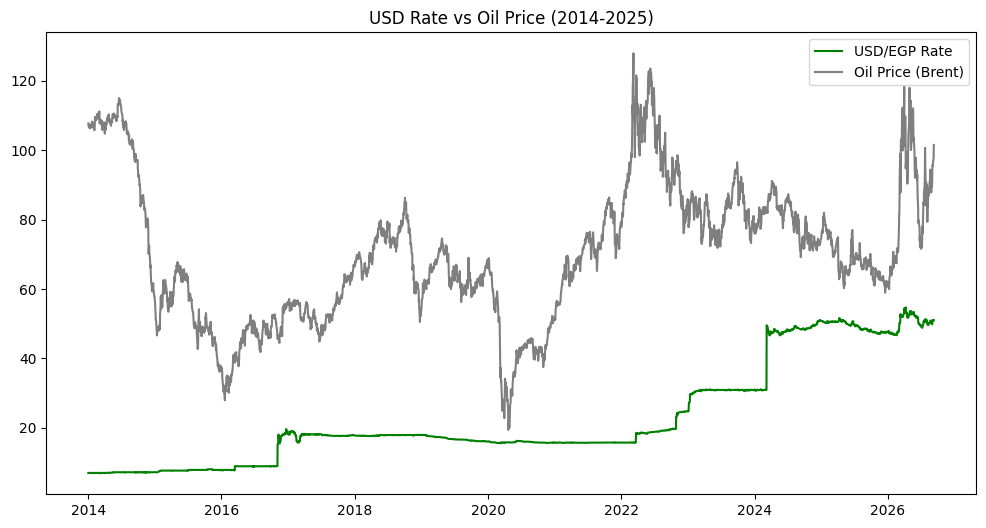

In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import datetime


# تحديد الفترة الزمنية (نفس فترة داتا البنزين بتاعتك)
start_date = "2014-01-01"
end_date = datetime.date.today().strftime("%Y-%m-%d")

print("Loading global data... ⏳")

# 1. تحميل سعر خام برنت (Brent Crude Oil)
oil_data = yf.download("BZ=F", start=start_date, end=end_date)
oil_data = oil_data[['Close']].rename(columns={'Close': 'Oil_Price_USD'})

# 2. تحميل سعر الدولار مقابل الجنيه (USD to EGP)
currency_data = yf.download("EGP=X", start=start_date, end=end_date)
currency_data = currency_data[['Close']].rename(columns={'Close': 'USD_EGP_Rate'})

# دمج البيانات في جدول واحد بناءً على التاريخ
market_factors = pd.merge(oil_data, currency_data, left_index=True, right_index=True, how='inner')

# إعادة تسمية المؤشر (Index) ليكون عمود عادي
market_factors.reset_index(inplace=True)

# عرض أول 5 سطور
print(market_factors.head())

# حفظ الملف عشان تستخدميه في الموديل
market_factors.to_csv('market_factors_history.csv', index=False)
print("✅ Market factors file (oil and USD) saved successfully!")

# رسم بياني سريع يوضح العلاقة
plt.figure(figsize=(12, 6))
plt.plot(market_factors['Date'], market_factors['USD_EGP_Rate'], label='USD/EGP Rate', color='green')
plt.plot(market_factors['Date'], market_factors['Oil_Price_USD'], label='Oil Price (Brent)', color='black', alpha=0.5)
plt.title('USD Rate vs Oil Price (2014-2025)')
plt.legend()
plt.show()